## Assignment 10 - Amol Singh

1. Carry out the following data understanding and integrity checks:

   a. How many rows and columns are present in the data?  
   b. How many rows and how many columns have missing data?

**Answer:** 

While trying to do **Exploratory data analysis (EDA)** the following are the observations w.r.t to the above questions

a. The dataset has **55500 rows** and **15 columns**

b. **Missing Data**
 - Rows with missing data: **8077 rows** have **missing** values.
 - Columns with missing data: 3 columns: Age, Medical Condition & Billing Amount has missing values
    - Age: **5550**
    - Medical Condition: **55**
    - Billing Amount: **2775**


In [86]:
import pandas as pd

file_path = 'data/healthcare_dataset_missing.csv'
data = pd.read_csv(file_path)

# Get the number of rows and columns
num_rows, num_columns = data.shape
print(f"Number of total rows: {num_rows}")
print(f"Number of total columns: {num_columns}")

Number of total rows: 55500
Number of total columns: 15


In [88]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

# if not duplicate_rows.empty:
#     print("Duplicate rows:")
#     print(duplicate_rows)

# Check for columns with missing values
missing_values = data.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]
print("\nColumns with missing values:")
print(columns_with_missing)

# Find the number of rows with missing data
rows_with_missing = data.isnull().any(axis=1).sum()
print(f"\nNumber of rows with missing data: {rows_with_missing}")

Number of duplicate rows: 451

Columns with missing values:
Age                  5550
Medical Condition      56
Billing Amount       2775
dtype: int64

Number of rows with missing data: 8077


2. Identify the level of measurement associated with each column

In [ ]:
#Before doing any data pre-processing, creating a duplicate csv file from the orginal csv
#Create a duplicate of the CSV file for pre-processing
duplicate_file_path = 'data/healthcare_dataset_cleaned.csv'
data.to_csv(duplicate_file_path, index=False)
print(f"Duplicate file created at: {duplicate_file_path}")

data_cleaned = data.drop_duplicates()
print(f"Number of rows after removing duplicates: {data_cleaned.shape[0]}")

# Save the cleaned data to the new file
cleaned_file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned.to_csv(cleaned_file_path, index=False)
print(f"Cleaned file saved at: {cleaned_file_path}")

#Confirming that the cleaned data does not have any duplicates
duplicate_rows = data_cleaned[data_cleaned.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned = pd.read_csv(file_path)

#Format names to title case and trim whitespace
if 'Name' in data_cleaned.columns:
    data_cleaned['Name'] = data_cleaned['Name'].str.strip().str.title()

#The mean imputation of the Age column is done below in the pipeline creation to avoid any data leakage in train and test split in the future steps of the assignment
#Impute missing ages with the mean age
# if 'Age' in data_cleaned.columns:
#     mean_age = data_cleaned['Age'].mean(skipna=True)
#     floored_mean_age = int(mean_age)  # Floor the mean age to the nearest integer
#     data_cleaned['Age'] = data_cleaned['Age'].fillna(floored_mean_age)


#Removing empty rows for Billing Amount and Medical Condition as the total data is less than 5-10%
data_cleaned = data_cleaned.dropna(subset=['Medical Condition', 'Billing Amount'])

#Add a new column for total days between admission and discharge
if 'Date of Admission' in data_cleaned.columns and 'Discharge Date' in data_cleaned.columns:
    # Convert dates to datetime format
    data_cleaned['Date of Admission'] = pd.to_datetime(data_cleaned['Date of Admission'], errors='coerce')
    data_cleaned['Discharge Date'] = pd.to_datetime(data_cleaned['Discharge Date'], errors='coerce')
    
    # Calculate the difference in days
    data_cleaned['Total Days'] = (data_cleaned['Discharge Date'] - data_cleaned['Date of Admission']).dt.days

#Save the updated dataset
updated_file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned.to_csv(updated_file_path, index=False)
print(f"Updated dataset saved at: {updated_file_path}")


Duplicate file created at: data/healthcare_dataset_cleaned.csv
Number of rows after removing duplicates: 55049
Cleaned file saved at: data/healthcare_dataset_cleaned.csv
Number of duplicate rows: 0
Updated dataset saved at: data/healthcare_dataset_cleaned.csv


3. Create appropriate descriptive statistics for every column, based on its level of measurement, and organize the results into tables for easy analysis and decision-making.

    a. Analyze the descriptive statistics generated and provide initial conclusions.

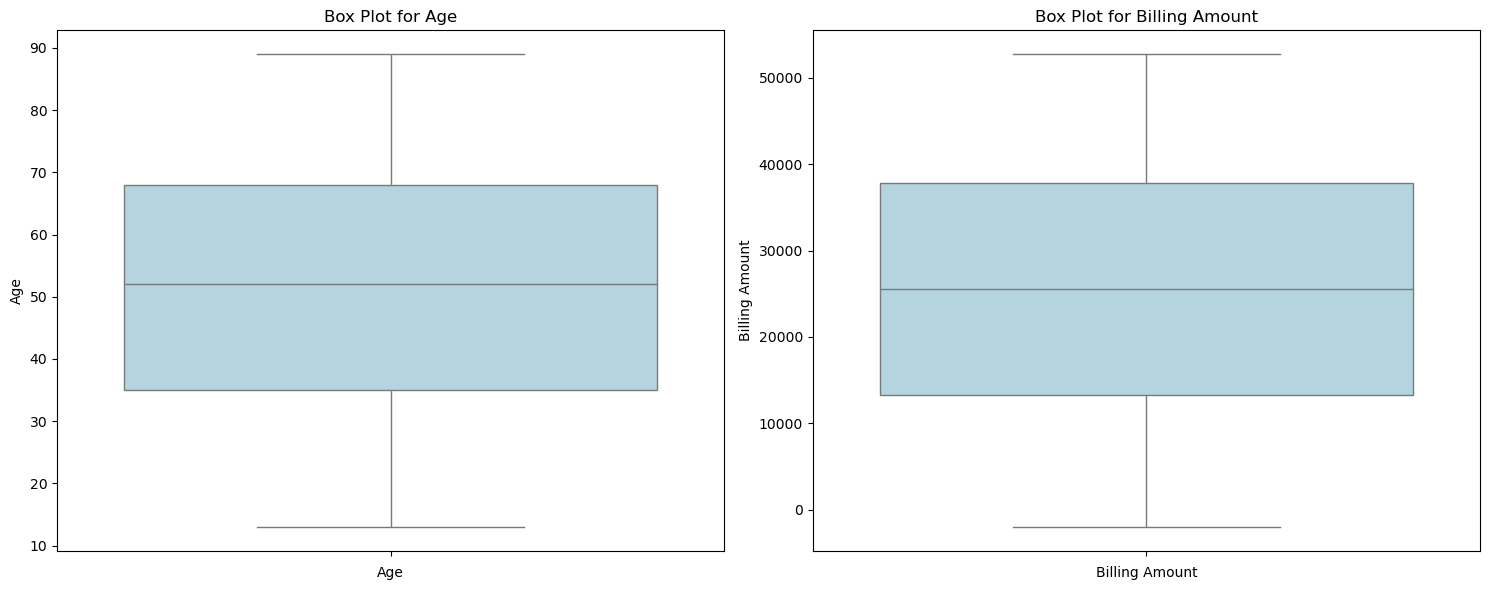

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned = pd.read_csv(file_path)

# Columns to plot
columns_to_plot = ['Age', 'Billing Amount']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns

# Plot box plots for the selected columns
for i, column in enumerate(columns_to_plot):
    sns.boxplot(data=data_cleaned[column], ax=axes[i], color="lightblue")
    axes[i].set_title(f"Box Plot for {column}")
    axes[i].set_xlabel(column)

# Adjust layout
plt.tight_layout()
plt.show()



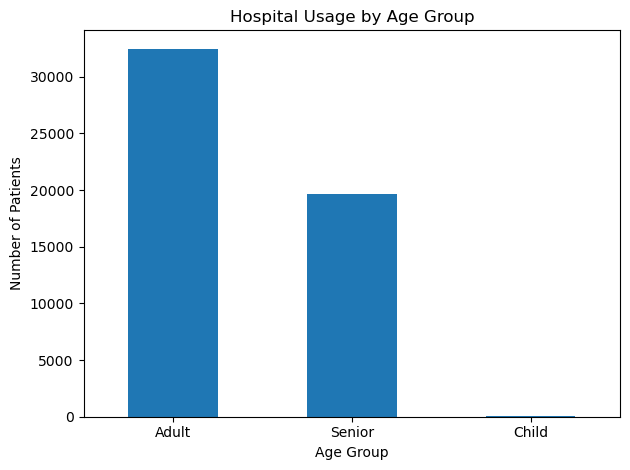

In [91]:
#Who dominates hospital usage?

def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 65:
        return 'Adult'
    else:
        return 'Senior'

data_cleaned['Age Group'] = data_cleaned['Age'].apply(age_group)

age_counts = data_cleaned['Age Group'].value_counts()
age_counts.plot(kind='bar')
plt.title('Hospital Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

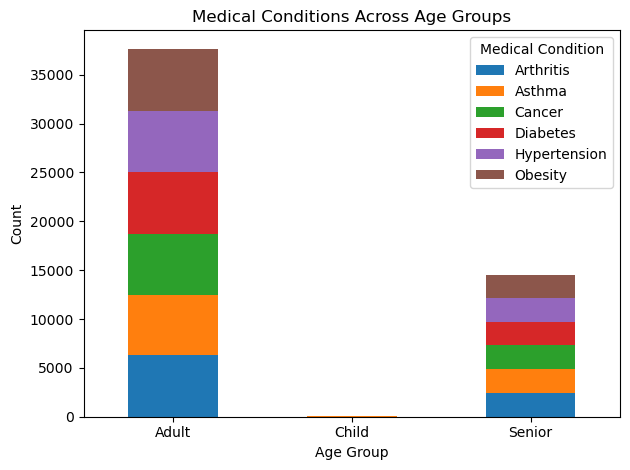

In [81]:
# What conditions affect each age group?

age_condition = data_cleaned.groupby(['Age Group', 'Medical Condition']).size().unstack(fill_value=0)
age_condition.plot(kind='bar', stacked=True)
plt.title('Medical Conditions Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

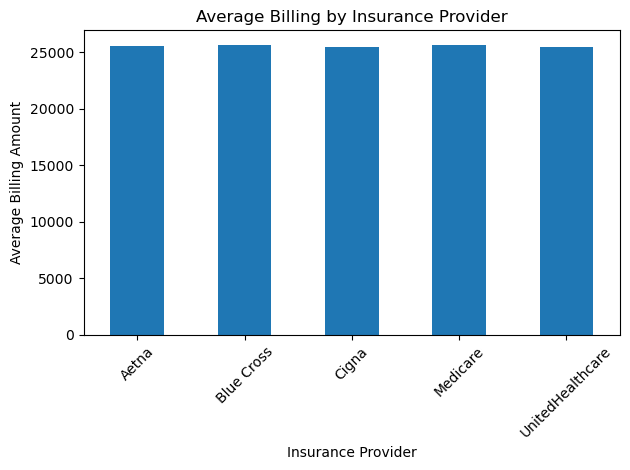

In [92]:
#Financial Burden (Insurance vs Billing) 

insurance_cost = data_cleaned.groupby('Insurance Provider')['Billing Amount'].mean()
insurance_cost.plot(kind='bar')
plt.title('Average Billing by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

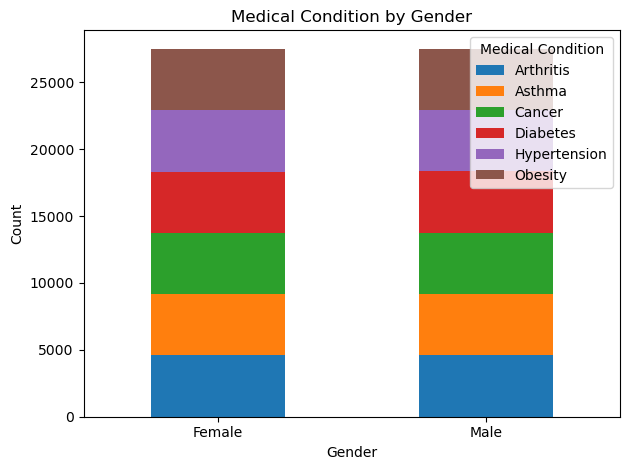

In [68]:
#Gender and Disease Patterns

gender_condition = data_cleaned.groupby(['Gender', 'Medical Condition']).size().unstack(fill_value=0)
gender_condition.plot(kind='bar', stacked=True)
plt.title('Medical Condition by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

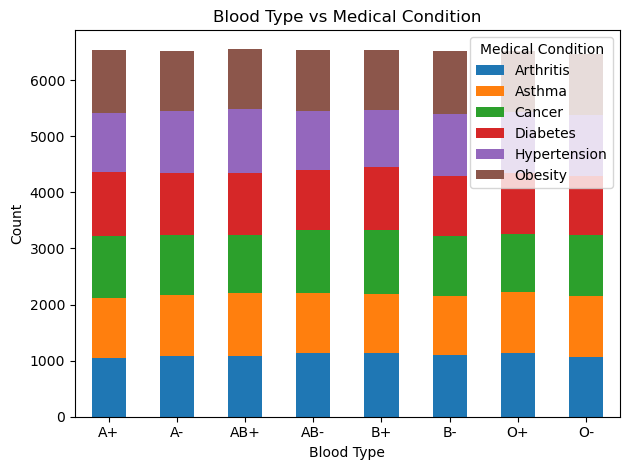

In [93]:
#Blood Type vs Medical Condition

blood_condition = data_cleaned.groupby(['Blood Type', 'Medical Condition']).size().unstack(fill_value=0)
blood_condition.plot(kind='bar', stacked=True)
plt.title('Blood Type vs Medical Condition')
plt.xlabel('Blood Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

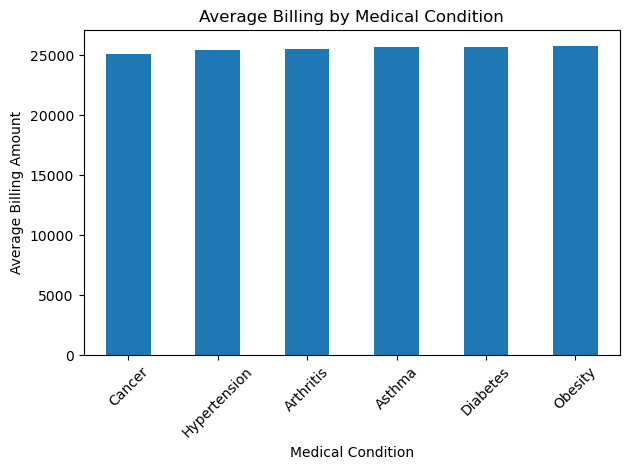

In [70]:
#Cost vs Condition

condition_cost = data_cleaned.groupby('Medical Condition')['Billing Amount'].mean().sort_values()
condition_cost.plot(kind='bar')
plt.title('Average Billing by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Is this data a time-series data? Do you expect any trends in each of the columns? Can 
you make any conclusions by creating a scatter plot of values of each column?

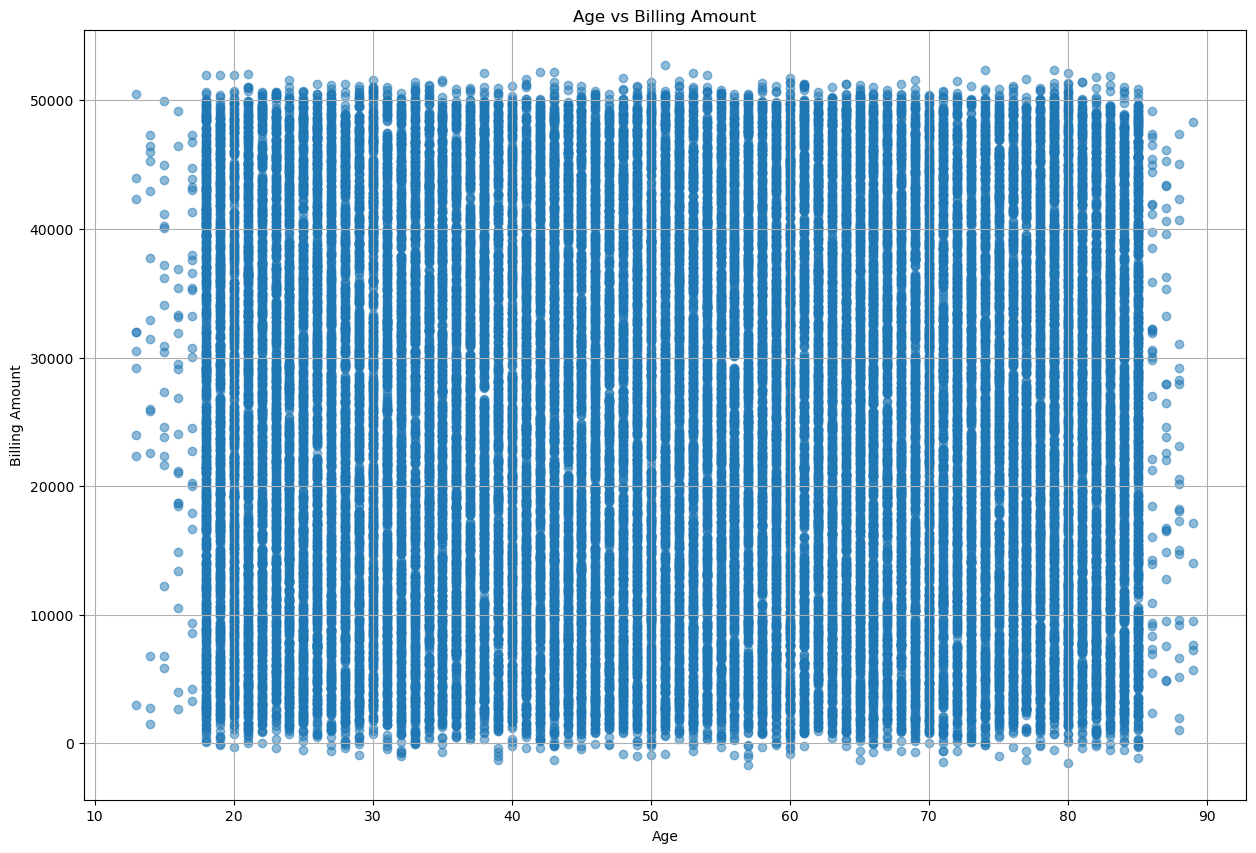

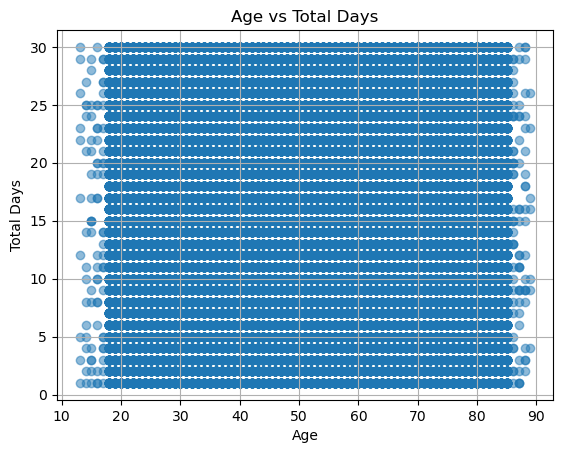

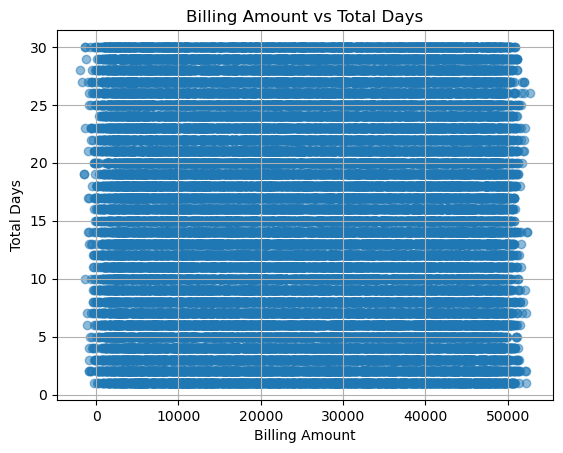

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned = pd.read_csv(file_path)

# Numerical columns to plot
numerical_columns = ['Age', 'Billing Amount', 'Total Days']

# Create scatter plots for each pair of numerical columns
plt.figure(figsize=(15, 10))
for i, col1 in enumerate(numerical_columns):
    for j, col2 in enumerate(numerical_columns):
        if i < j:  # Avoid duplicate plots
            plt.scatter(data_cleaned[col1], data_cleaned[col2], alpha=0.5)
            plt.xlabel(col1)
            plt.ylabel(col2)
            plt.title(f'{col1} vs {col2}')
            plt.grid(True)
            plt.show()

5. Based on the information available so far, what will be your strategy for dealing with the 
missing values? Make some initial decisions at this stage. 

**Answer**

We are following the below strategy for the missing values:
1. Age - Populating the missing age with the mean age of the sample as the missing values is little more around 5000. This is done below in the pipeline created to be handled appropriately after the test and trai split in the pipeline created below
2. Billing Amount - Removing the rows having missing Billing amount as the billing amount is a target variable and the missing rows constitute a very small amount of total data 5-10%
3. Medical Condition - Removing the rows having missing Medical condition as the Medical condition are very few in number and should not result in any data fluctuation

6. Analyze the Age column with the help of appropriate visualizations. What can you 
conclude? Are there any missing values in this column? How will you handle them? 
Why?

**Answer**


We are following the below strategy for Age:
1. Age - Populating the missing age with the mean age of the sample as the missing values is little more around 5000

7. Create histograms and KDE plots (find out what KDE plots represent) for all the columns 
and analyze them. Any significant conclusions? 

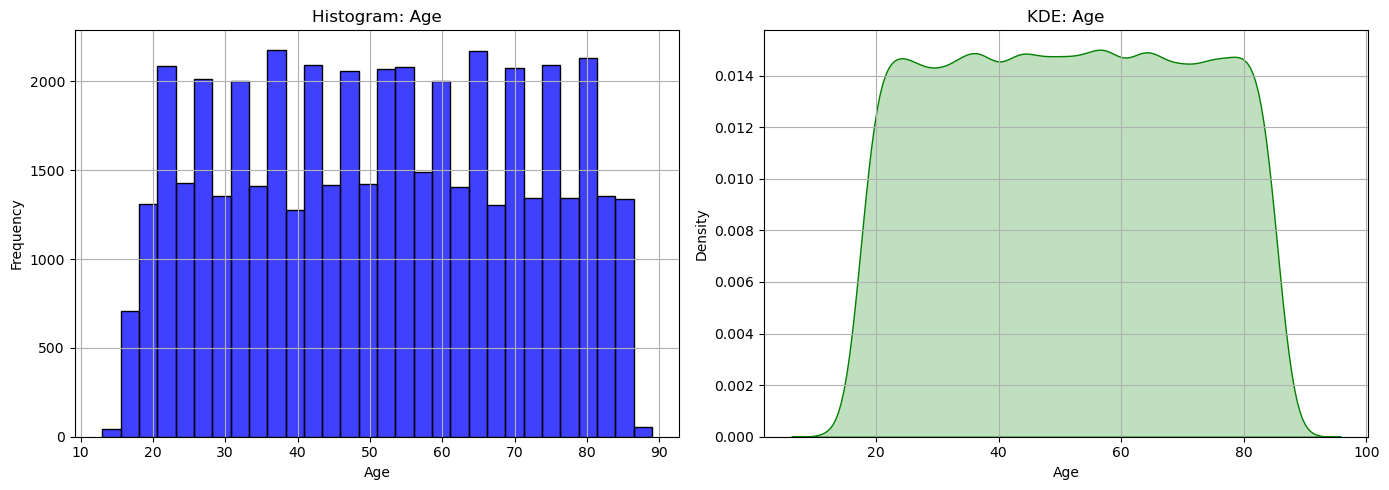

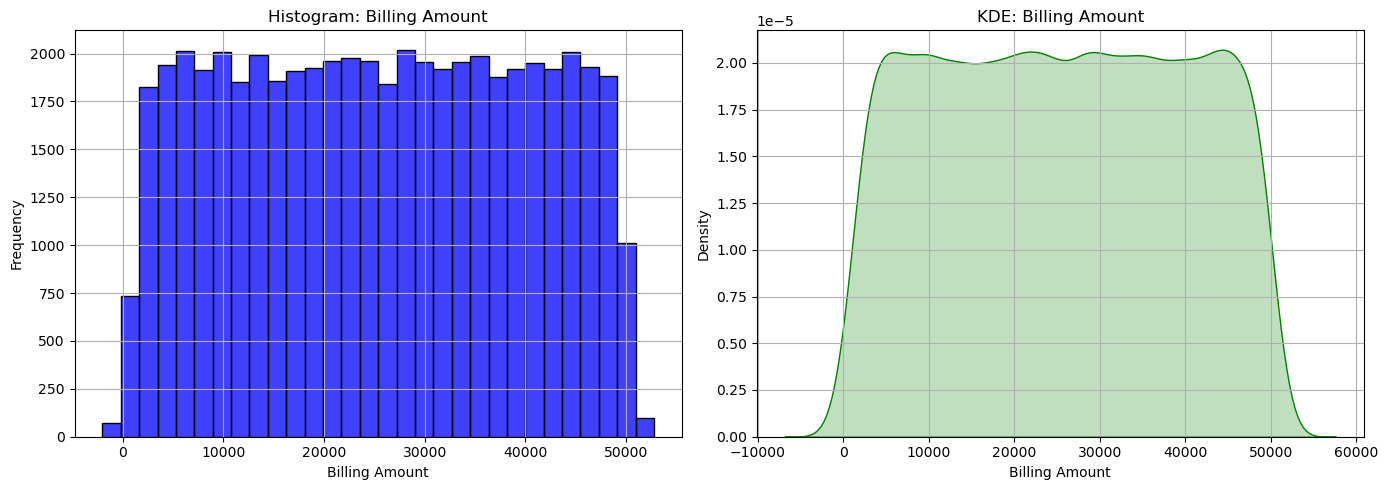

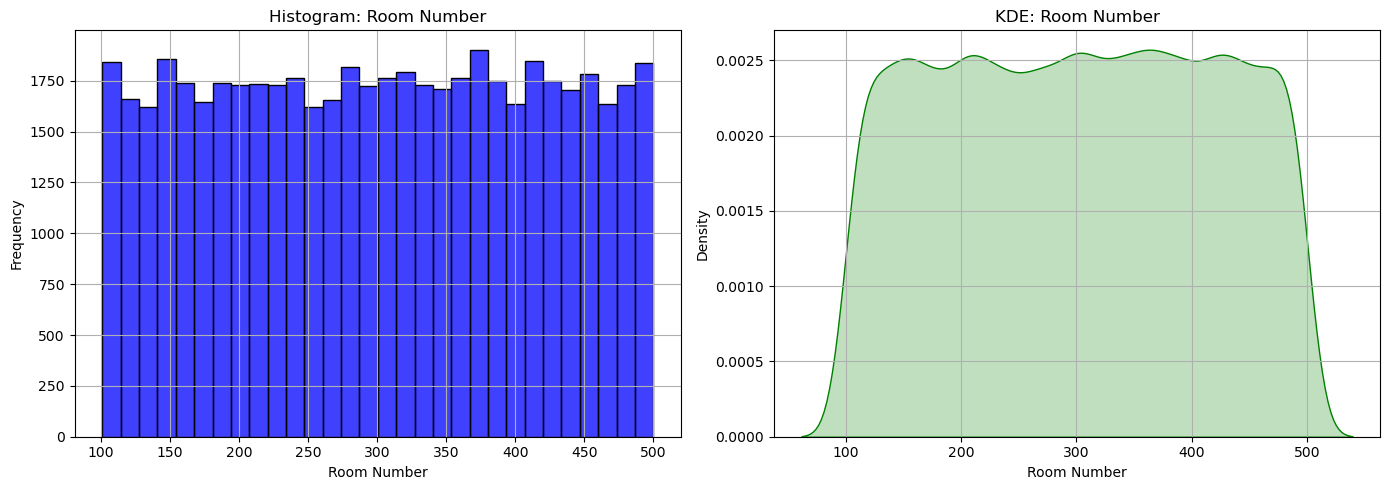

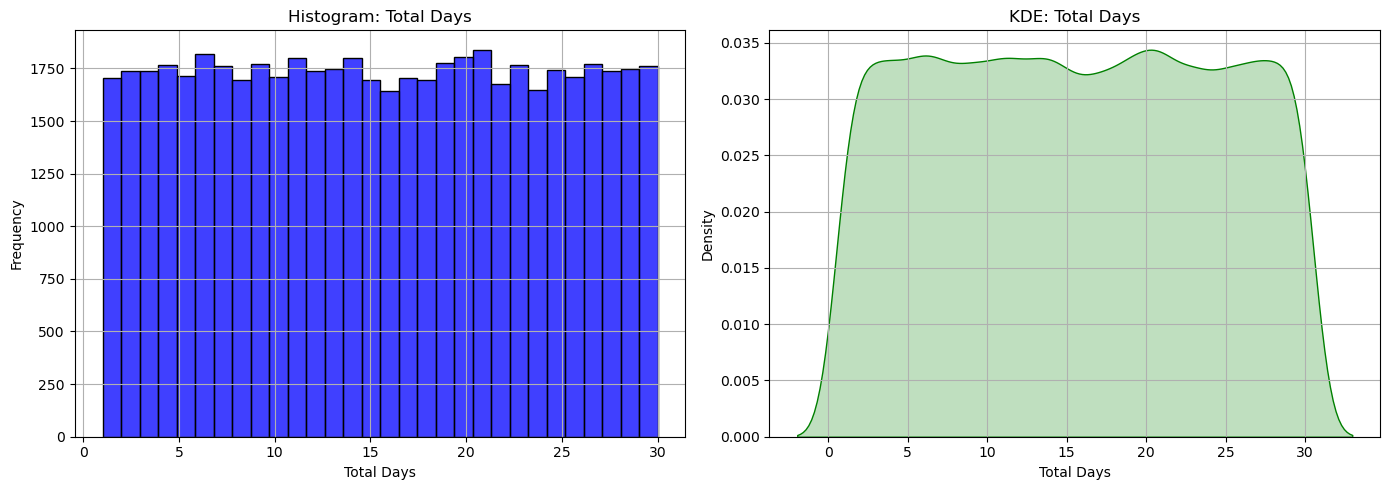

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned = pd.read_csv(file_path)

# Iterate through numerical columns
for column in data_cleaned.columns:
    if pd.api.types.is_numeric_dtype(data_cleaned[column]):
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Histogram (BLUE)
        sns.histplot(
            data_cleaned[column],
            kde=False,
            bins=30,
            color='blue',
            ax=axes[0]
        )
        axes[0].set_title(f"Histogram: {column}")
        axes[0].set_xlabel(column)
        axes[0].set_ylabel("Frequency")
        axes[0].grid(True)

        # KDE Plot (GREEN)
        sns.kdeplot(
            data_cleaned[column],
            fill=True,
            color='green',
            ax=axes[1]
        )
        axes[1].set_title(f"KDE: {column}")
        axes[1].set_xlabel(column)
        axes[1].set_ylabel("Density")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

8. Create box plots for all the columns, individually, and analyze them. What are your 
conclusions?

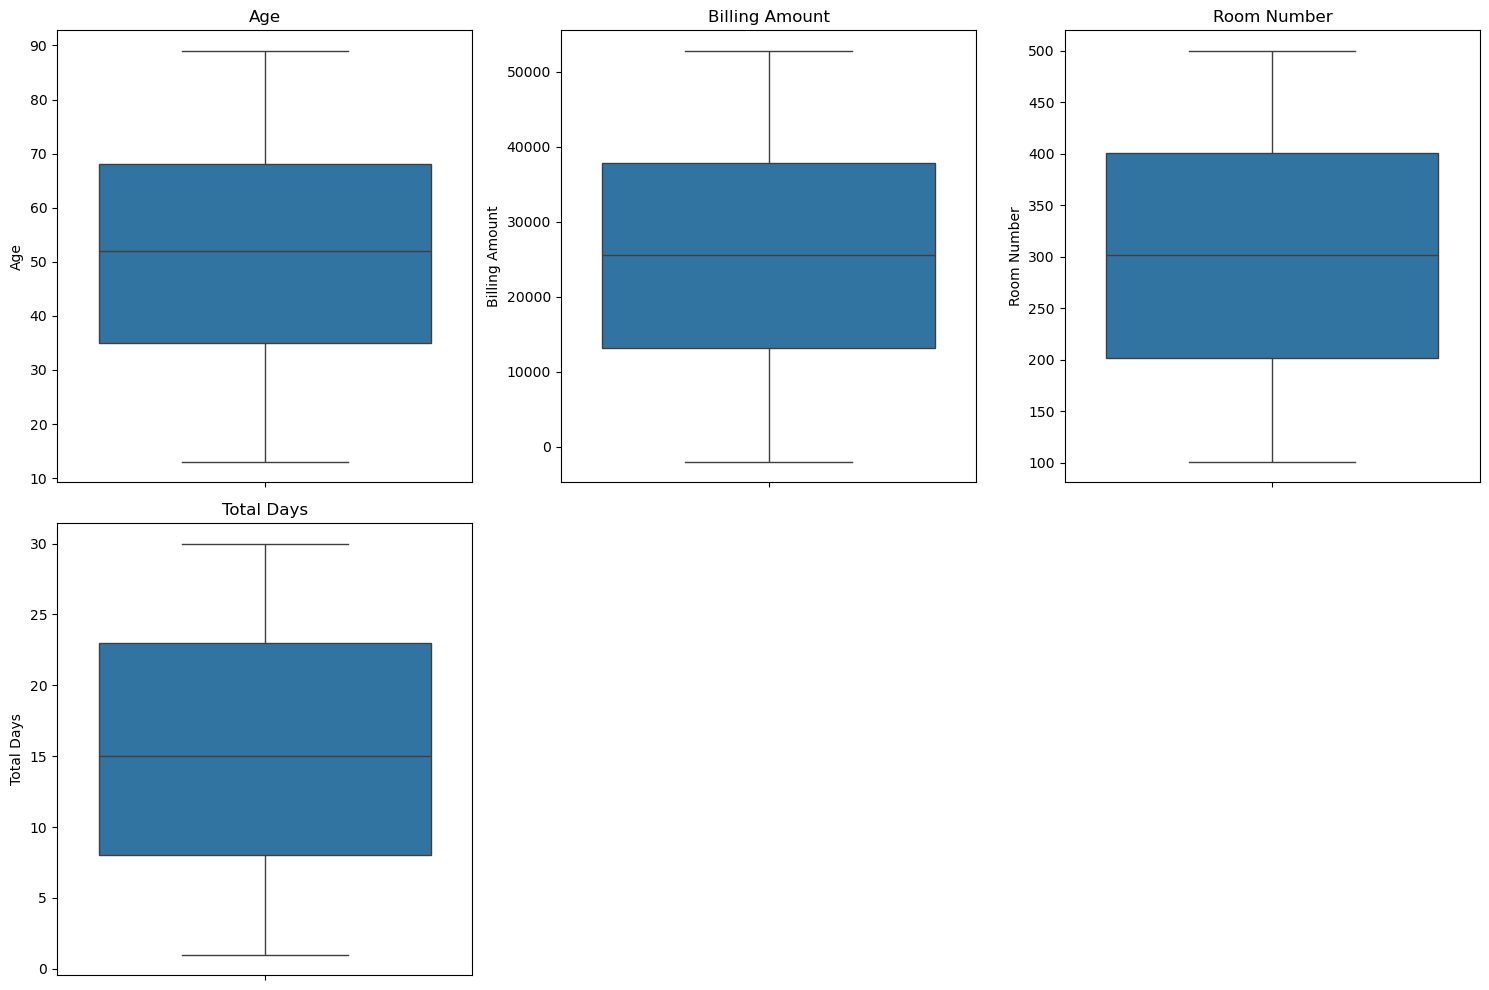

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load dataset
df = pd.read_csv("data/healthcare_dataset_cleaned.csv")

# Select only numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Define subplot grid size
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Plot each boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col}")

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

9. Create box plots for all the numerical columns on a common scale, and in a single plot, 
and analyze this plot. What do you observe? What are its implications? 

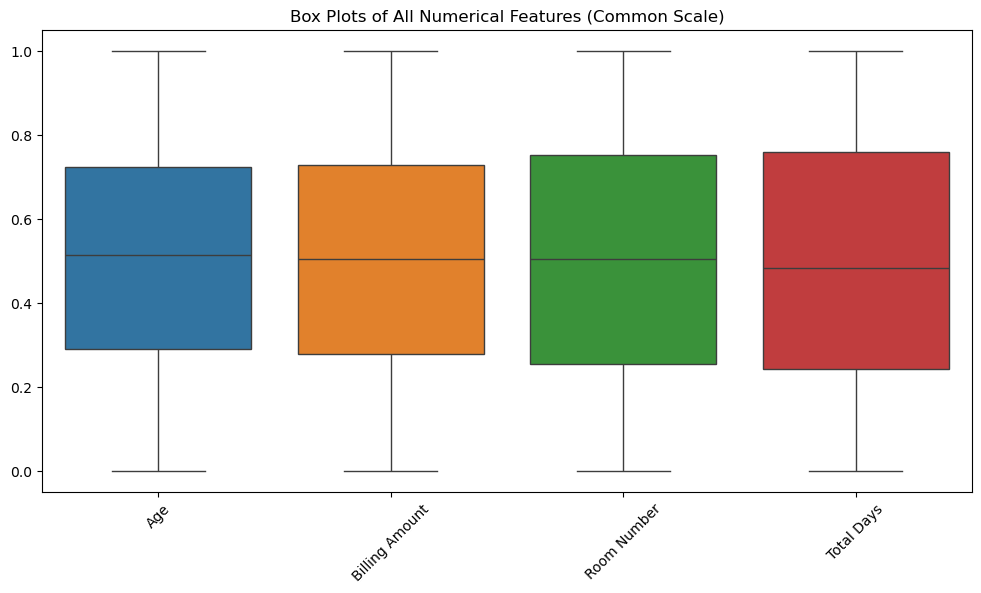

In [97]:
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("data/healthcare_dataset_cleaned.csv")

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Scale data to common range [0,1]
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)

# Single combined box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled)
plt.title("Box Plots of All Numerical Features (Common Scale)")
plt.xticks(rotation=45)
plt.show()

10. To understand the relationships between the columns, perform the following analyses:

    a. Create pairwise scatter plots to visualize relationships between variables  
    b. Generate a heatmap of pairwise correlation coefficients  
    c. Analyze the plots and summarize your conclusions

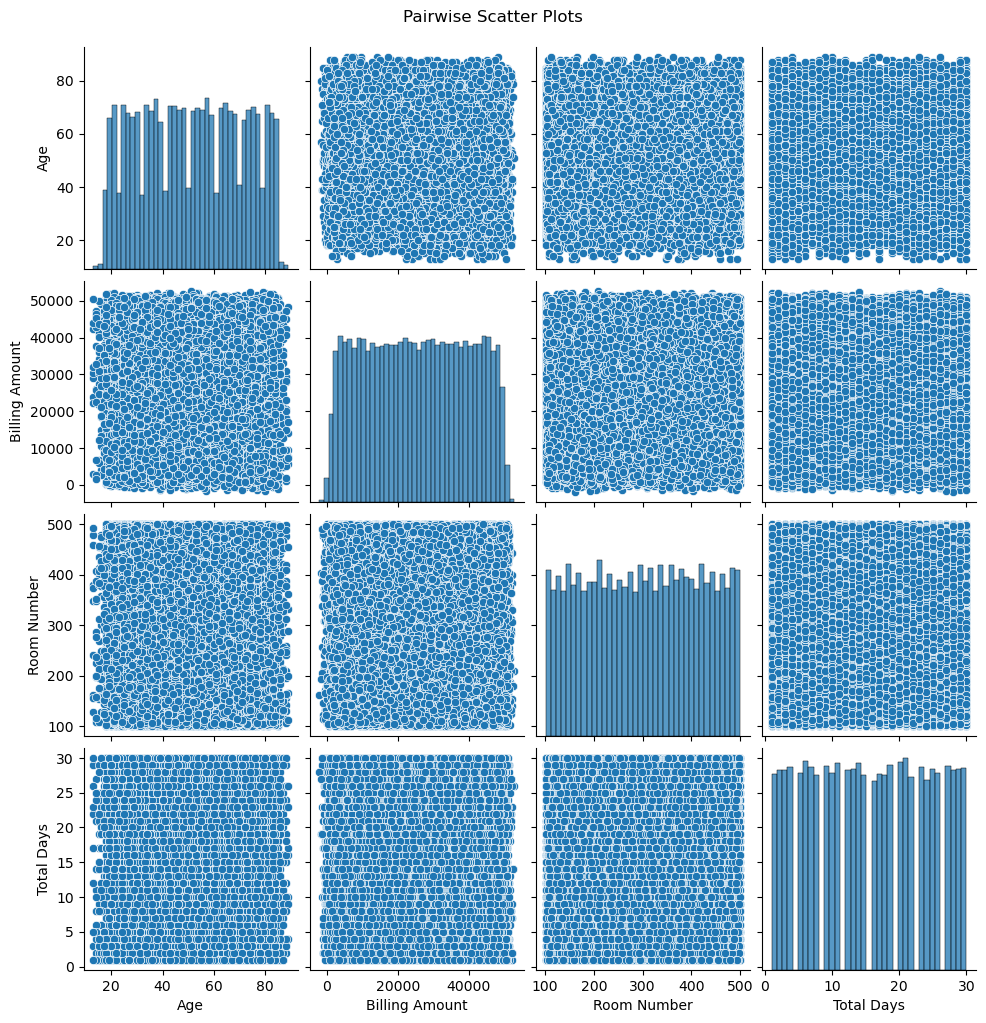

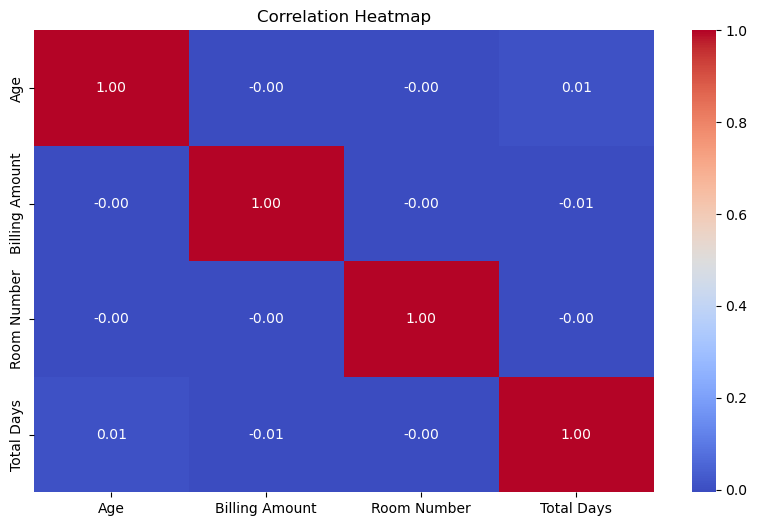

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/healthcare_dataset_cleaned.csv")

# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# -----------------------------
# a. Pairwise Scatter Plots
# -----------------------------
sns.pairplot(num_df)
plt.suptitle("Pairwise Scatter Plots", y=1.02)
plt.show()

# -----------------------------
# b. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10, 6))
corr_matrix = num_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

11. Based on all the analysis so far, what is your final conclusion regarding the handling of 
missing values? Implement your decision! 

**Age**
 - Replacing the missing values with the mean of age
 - The mean being a decimal value we are flooring it, rounding it off before replacing with empty

 **Billing Amount**
 - Replacing the billing amount with the mean of the Billing amount
 - Since there is no trend observed between the number of days and the amount we are not in a position of imputing the values based on the number of days
 - We have taken a mean of the Billing amount and replaced the empty values

 **Medical Condition**
 - For Medical condition we are not making any change as it is a categorical value and we cannot just put a random category

 The above are already implemented above

12. Using a suitable pipeline approach (with `sklearn.pipeline`), implement scaling, transformation, and Linear Regression to predict the **Billing Amount**.


- Drop irrelevant columns (e.g., `Name`, `Doctor`, `Hospital`)
- Convert `Date of Admission` and `Discharge Date` into datetime format
- Create a new feature:
  - **Length of Stay** = Difference (in days) between `Discharge Date` and `Date of Admission`
- Remove the original date columns after creating the new feature
- Encode all categorical variables appropriately
- Split the dataset into training and testing sets

- Apply preprocessing and model training using an `sklearn` pipeline
- Use Linear Regression as the model

Report performance metrics for both training and testing datasets.

In [101]:
import pandas as pd

data_cleaned = pd.read_csv("data/healthcare_dataset_cleaned.csv")

# Check for columns with missing values
missing_values = data_cleaned.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]
print("\nColumns with missing values:")
print(columns_with_missing)

# Find the number of rows with missing data
rows_with_missing = data_cleaned.isnull().any(axis=1).sum()
print(f"\nNumber of rows with missing data: {rows_with_missing}")


Columns with missing values:
Age    5190
dtype: int64

Number of rows with missing data: 5190


In [104]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# -------------------------------
# Custom Transformer
# -------------------------------
class FloorTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return np.floor(X)

# -------------------------------
# Load data
# -------------------------------
df = pd.read_csv("data/healthcare_dataset_cleaned.csv")

df = df.drop(columns=["Name", "Doctor", "Hospital"], errors="ignore")

df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], errors="coerce")
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], errors="coerce")

df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

df = df.drop(columns=["Date of Admission", "Discharge Date"])

df = df.dropna(subset=["Billing Amount"])

# -------------------------------
# Split
# -------------------------------
X = df.drop(columns=["Billing Amount"])
y = df["Billing Amount"]

# Clean column names (important!)
X.columns = X.columns.str.strip()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Remove Age from numerical list
numerical_cols = [col for col in numerical_cols if col != "Age"]

# -------------------------------
# Pipelines
# -------------------------------

# Age pipeline
age_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("floor", FloorTransformer()),
    ("scaler", StandardScaler())  # keep numeric stable
])

# Other numerical columns
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# -------------------------------
# Preprocessor
# -------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("age", age_pipeline, ["Age"]),
        ("num", num_pipeline, numerical_cols),
        ("cat", cat_pipeline, categorical_cols),
    ]
)

# -------------------------------
# Full pipeline
# -------------------------------
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Fit
# -------------------------------
pipeline.fit(X_train, y_train)

# -------------------------------
# Predict
# -------------------------------
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# -------------------------------
# Evaluate
# -------------------------------
def evaluate(y_true, y_pred, name):
    print(f"\n{name} Performance:")
    print("R2:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))

evaluate(y_train, y_train_pred, "Train")
evaluate(y_test, y_test_pred, "Test")


Train Performance:
R2: 0.0007016093343400476
MAE: 12299.991518814682
MSE: 202070527.85449246

Test Performance:
R2: -5.692027482462336e-05
MAE: 12301.327889447917
MSE: 202018873.32435414


/var/folders/wp/th3b19fs1lj592c5288s9htm0000gn/T/ipykernel_34226/1772180734.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
#Trying Random Forest ML algorithm to train and test the above dataset

# -------------------------------
# Random Forest Model
# -------------------------------
from sklearn.ensemble import RandomForestRegressor

pipeline_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,        # more trees → better stability
        max_depth=10,            # limit tree depth → reduce overfitting
        min_samples_split=10,    # avoid very small splits
        min_samples_leaf=5,      # smoother predictions
        random_state=42,
        n_jobs=-1
    ))
])

# -------------------------------
# Train
# -------------------------------
pipeline_rf.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_train_pred_rf = pipeline_rf.predict(X_train)
y_test_pred_rf = pipeline_rf.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
evaluate(y_train, y_train_pred_rf, "Train (Random Forest)")
evaluate(y_test, y_test_pred_rf, "Test (Random Forest)")


Train (Random Forest) Performance:
R2: 0.0799794806960541
MAE: 11794.013464564863
MSE: 186039559.06390837

Test (Random Forest) Performance:
R2: 0.004887220797475278
MAE: 12260.706136420578
MSE: 201020120.3646644


13. Scale the numerical columns in the dataset using an appropriate technique (such as 
Min-Max Scaling or Standardization). After scaling, re-create a common-scale box plot 
for all numerical variables in a single plot. 

Scaled dataset saved at: data/healthcare_dataset_scaled.csv


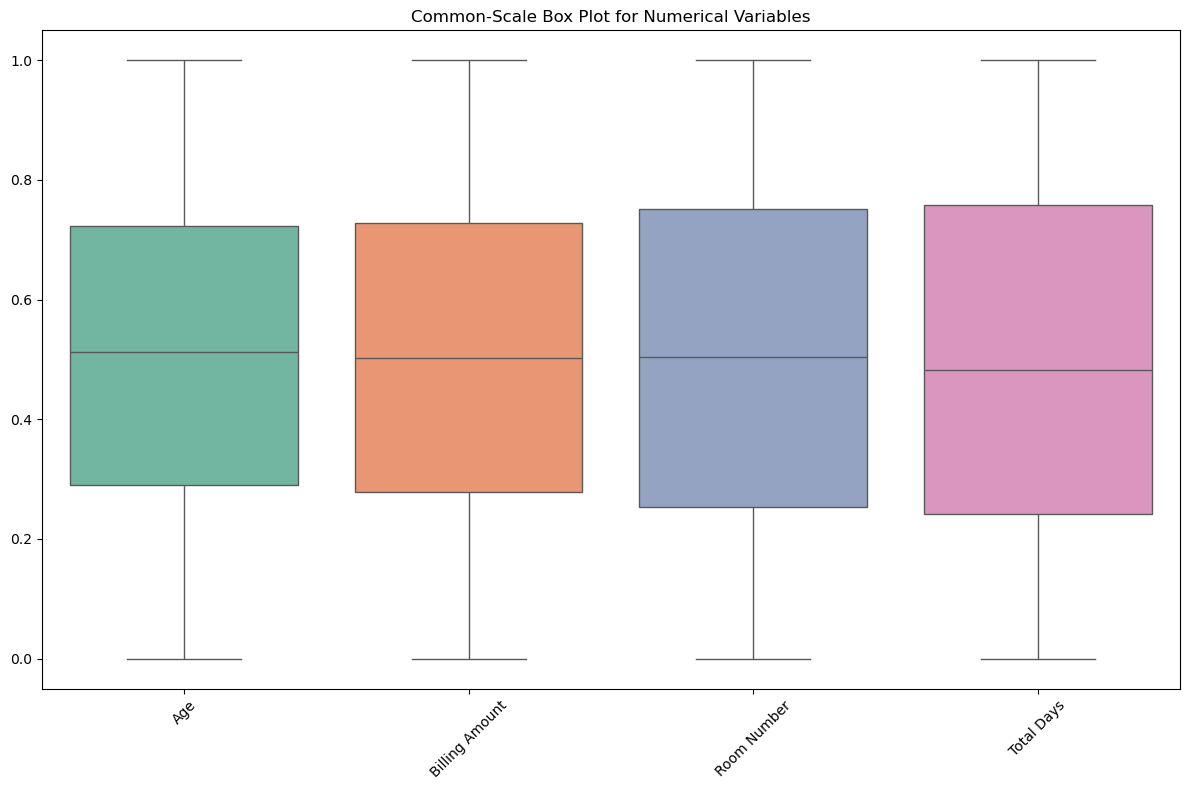

In [105]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
file_path = 'data/healthcare_dataset_cleaned.csv'
data_cleaned = pd.read_csv(file_path)

# Select numerical columns for scaling
numerical_columns = data_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Apply Min-Max Scaling
scaler = MinMaxScaler()
data_cleaned[numerical_columns] = scaler.fit_transform(data_cleaned[numerical_columns])

# Save the scaled dataset (optional)
scaled_file_path = 'data/healthcare_dataset_scaled.csv'
data_cleaned.to_csv(scaled_file_path, index=False)
print(f"Scaled dataset saved at: {scaled_file_path}")

# Create a common-scale box plot for all numerical columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=data_cleaned[numerical_columns], palette="Set2")
plt.title("Common-Scale Box Plot for Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

14. Compare this plot with the earlier box plot (before scaling) and analyze how scaling has 
affected the distribution, spread, and presence of outliers. Interpret your observations. 
Additionally, create correlation heatmaps before and after scaling, and compare them. 
What are your observations? 

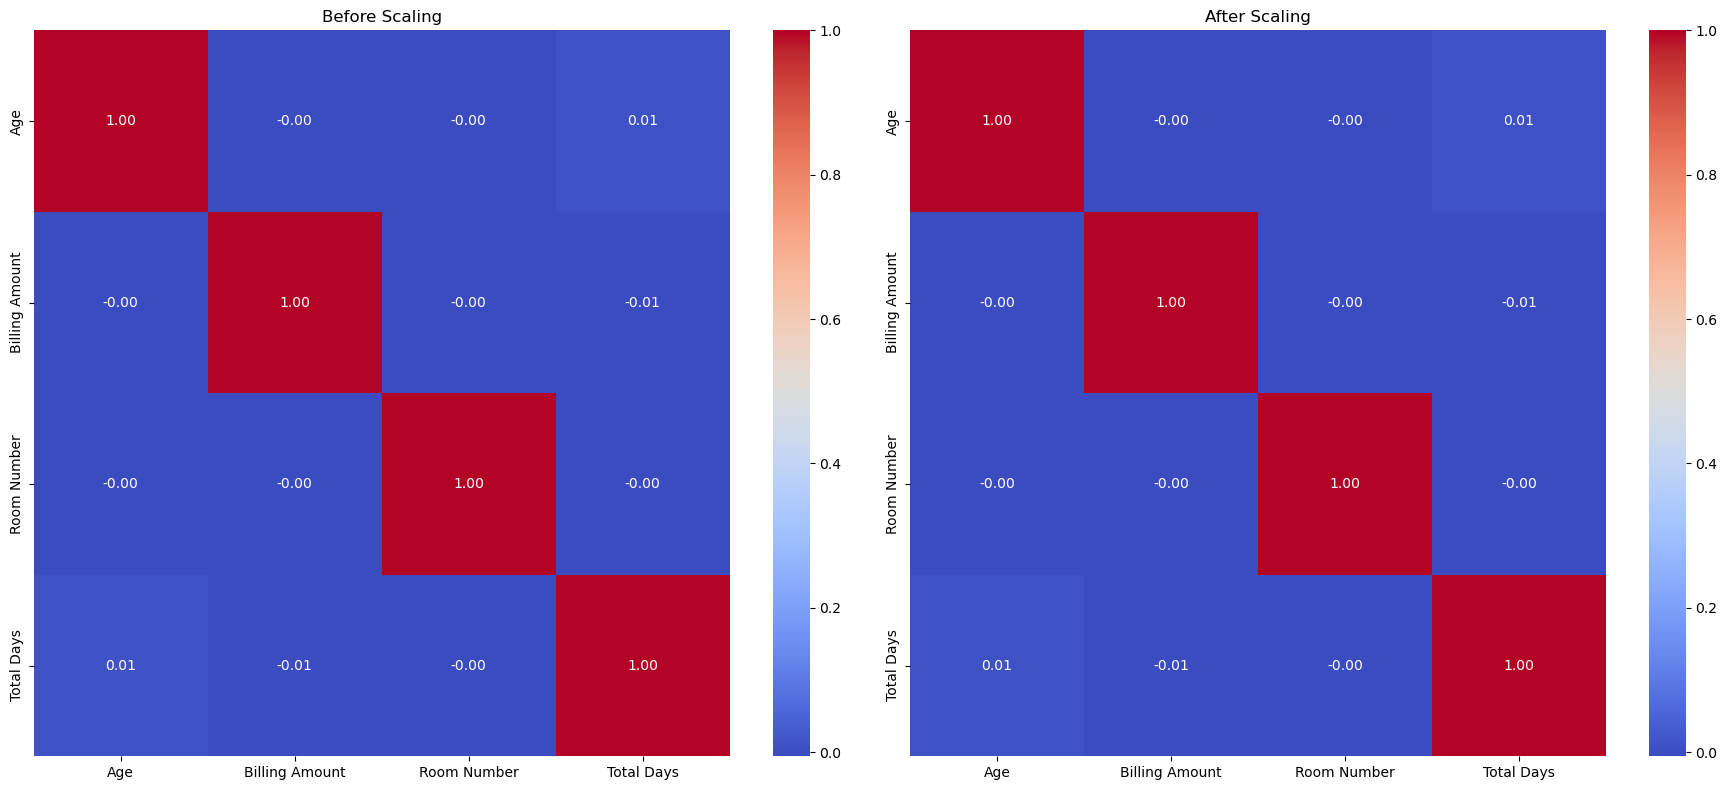

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load scaled data
df_scaled = pd.read_csv("data/healthcare_dataset_scaled.csv")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap BEFORE scaling
sns.heatmap(
    data_cleaned[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("Before Scaling")

# Heatmap AFTER scaling
sns.heatmap(
    df_scaled[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

## Analysis of Box Plots (Before and After Scaling)

### Distribution

- **Before Scaling:**  
  The box plots showed numerical columns with varying ranges, making it difficult to compare distributions directly.

- **After Scaling:**  
  Min-Max Scaling transformed all numerical columns to the same range \([0, 1]\). This allows for direct comparison of distributions across columns.

### Spread

- **Before Scaling:**  
  The spread (range and interquartile range) varied significantly across features, with some columns having much larger variability than others.

- **After Scaling:**  
  The spread of all features became normalized within the same range, making differences in variability easier to observe and compare.

### Outliers

- **Before Scaling:**  
  Outliers were visible as points outside the whiskers of the box plots, with their magnitude depending on the column's scale.

- **After Scaling:**  
  Outliers are still present but are now scaled to the \([0, 1]\) range. Their relative positions remain the same, but their absolute values are normalized.

---

## Correlation Heatmaps (Before and After Scaling)

### Before Scaling

- The correlation heatmap reflects the relationships between columns based on their original scales.  
- Correlation values are unaffected by the scale of the data, as correlation measures the strength of linear relationships.

### After Scaling

- The correlation heatmap remains the same as before scaling because scaling does not affect the linear relationships between variables.

---

## Observations

- **Scaling Impact:**  
  Scaling does not change the underlying data distribution or relationships but makes numerical columns comparable on the same scale.

- **Outliers:**  
  Outliers remain visible after scaling, but their values are normalized.

- **Correlation:**  
  Correlation coefficients are unaffected by scaling, as they are scale-invariant.